# Debugging xy shift in WN regen

In [2]:
import retinanalysis as ra
import numpy as np
import matplotlib.pyplot as plt
import mat73
from scipy.io import loadmat
import os
print(ra.settings.ANALYSIS_DIR)
import sys
# sys.path.append('/home/vyomr/Desktop/gitrepos/retinanalysis/src/retinanalysis/utils/')
sys.path.append('/Users/riekelabbackup/Desktop/Vyom/RetinAnalysis/src/retinanalysis/utils/')
import regen
import importlib
importlib.reload(regen)
import cv2

[2025-11-22 09:58:11,764][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306


No NAS or SSD paths found, check that one of them is connected



## no jitter case

In [3]:
exp_name = 'noise_test_0921'
df_exp = ra.get_exp_summary(exp_name)
df_exp

,exp_name,prep_label,cell_id,cell_label,cell_type,NDF,protocol_name,duration_minutes,minutes_since_start,start_time,end_time,cell_properties,group_label,experiment_id,prep_id,group_id,block_id,protocol_id
0,noise_test_0921,mount1,208,noise_testm1,RGC,0.5,manookinlab.protocols.SpatialNoise,0.18,0.18,2025-11-21 12:59:36,2025-11-21 12:59:47,{'type': 'RGC'},phone_photo,174,202,2711,4097,19
1,noise_test_0921,mount1,208,noise_testm1,RGC,4.0,manookinlab.protocols.SpatialNoise,0.20,3.03,2025-11-21 13:02:26,2025-11-21 13:02:38,{'type': 'RGC'},screencap,174,202,2712,4098,19


In [13]:
canvas_size = (1140, 1824)

bid = df_exp.at[0, 'block_id']
sb0 = ra.StimBlock(exp_name, bid)

bid = df_exp.at[1, 'block_id']
sb1 = ra.StimBlock(exp_name, bid)

Initializing StimBlock for noise_test_0921 block 4097
Initializing StimBlock for noise_test_0921 block 4098


In [14]:
sb0.df_epochs.at[0, 'epoch_parameters']['numYStixels'], sb1.df_epochs.at[0, 'epoch_parameters']['numYStixels']

(44.0, 43.0)

In [15]:
sb0.df_epochs['group_label'].values[0], sb1.df_epochs['group_label'].values[0]

('phone_photo', 'screencap')

(1140, 905, 3)
(1140, 1810, 3)


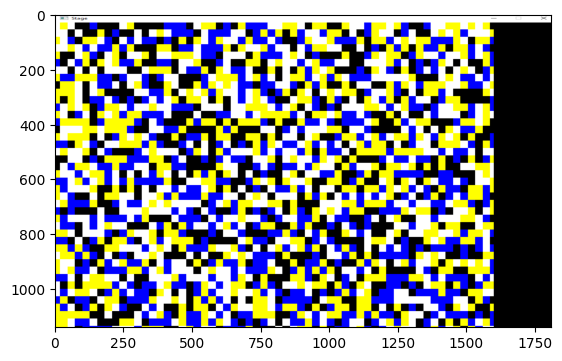

In [16]:
importlib.reload(regen)
str_pic1 = '/Volumes/data-1/noise_test_window_snip.png'



pic1 = cv2.imread(str_pic1)
pic1 = cv2.cvtColor(pic1, cv2.COLOR_BGR2RGB)
print(pic1.shape)
# Reshape to 2x on x
pic_size = pic1.shape
pic1 = cv2.resize(pic1, (pic_size[1]*2, pic_size[0]), interpolation=cv2.INTER_NEAREST)
print(pic1.shape)
plt.imshow(pic1)

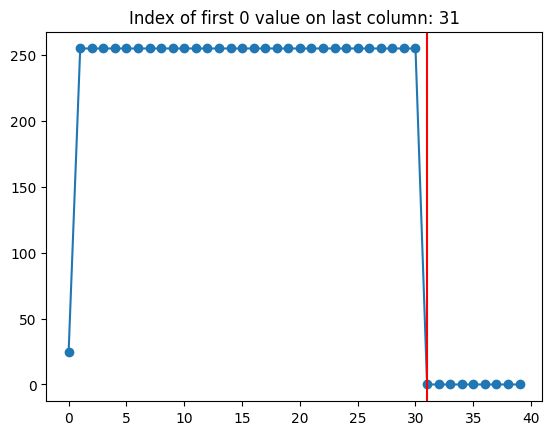

In [17]:
# Get first idx of 0 value on last column
ridx_0 = np.where(pic1[:,-1,0]==0)[0][0]

plt.plot(pic1[:40,-1,0], '-o')
plt.title(f'Index of first 0 value on last column: {ridx_0}')
plt.axvline(x=ridx_0, color='r')

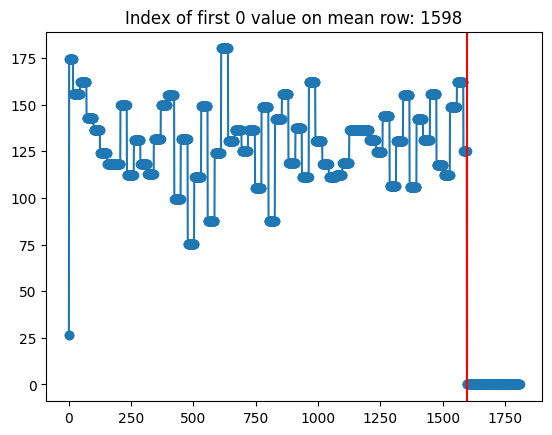

In [18]:
# Get last idx of 0 value from the right on mean row
mean_row = np.mean(pic1[ridx_0:,:,0], axis=0)
cidx_0 = np.where(mean_row==0)[0][0]
plt.plot(mean_row, '-o')
plt.title(f'Index of first 0 value on mean row: {cidx_0}')
plt.axvline(x=cidx_0, color='r')

Text(0.5, 1.0, 'Cropped size: (1109, 1598, 3)')

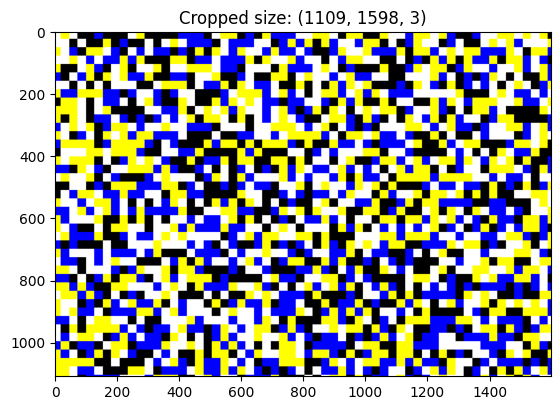

In [19]:
# Cropped pic1
cpic1 = pic1[ridx_0:, :cidx_0, :]
cropped_size = cpic1.shape
plt.imshow(cpic1)
plt.title(f'Cropped size: {cropped_size}')

In [20]:
def plot_frame_comparison(v_frames, r_frames):
    # if v_frames (0, 255), scale to (0, 1)
    if v_frames.max() > 1.0:
        v_frames = v_frames / 255.0
    # if r_frames (-1, 1), scale to (0, 1)
    if r_frames.min() < 0.0:
        r_frames = (r_frames + 1) / 2.0
    
    # if r_frames larger, crop to match v_frames
    if r_frames.shape[1:3] != v_frames.shape[1:3]:
        min_y = min(r_frames.shape[1], v_frames.shape[1])
        min_x = min(r_frames.shape[2], v_frames.shape[2])
        r_frames = r_frames[:, :min_y, :min_x, :]
        v_frames = v_frames[:, :min_y, :min_x, :]

    f, axs = plt.subplots(ncols=3, figsize=(15,10))
    ls_f = [v_frames, r_frames]
    ls_titles = ['Stage screencap', 'Python regen']
    i_frame = 0 # 3 has 0 offset
    ax = axs[0]
    f = ls_f[0][i_frame]
    f = f[...,0]
    # f = cv2.resize(f, (203, 127), interpolation=cv2.INTER_NEAREST)
    im=ax.imshow(f)
    ax.set_title(ls_titles[0])
    ax.axis('off')

    ax = axs[1]
    f = ls_f[1][i_frame]
    f = f[...,0]
    # f = cv2.resize(f, (203, 127), interpolation=cv2.INTER_NEAREST)
    im=ax.imshow(f)
    ax.set_title(ls_titles[1])
    ax.axis('off')

    ax = axs[2]
    f = ls_f[0][i_frame] - ls_f[1][i_frame]
    f = f[...,0]
    # Scale difference to 0, 1
    f = (f - f.min()) / (f.max() - f.min())
    # f = cv2.resize(f, (203, 127), interpolation=cv2.INTER_NEAREST)
    r = np.corrcoef(ls_f[0][i_frame].flatten(), ls_f[1][i_frame].flatten())[0,1]
    im=ax.imshow(f, cmap='viridis')#, vmin=-0.5, vmax=0.5)
    ax.set_title(f'Difference (r={r:.2f})')
    ax.axis('off')

In [21]:
canvas_size

(1140, 1824)

In [81]:
import importlib
importlib.reload(regen)
d_wn = regen.make_spatial_noise(sb0.df_epochs, canvas_size=canvas_size)
r_frames = d_wn['frames'][0]
# plot_frame_comparison(cpic1[np.newaxis], r_frames[:,10:])

100%|██████████| 1/1 [00:00<00:00, 14.35it/s]

numXStixels: 69.0, numYStixels: 44.0, numXChecks: 203.0, numYChecks: 127.0
chromaticClass: BY, unique_frames: 1, repeat_frames: 0
stepsPerStixel: 3.0, seed: 44741513.0, frameDwell: 1.0
gaussianFilter: 0, filterSdStixels: 1.0
Grid size: 9 pix, Stixel size: 27.0 pix
gridValues: (2, 3036)
gridValues: (2, 44, 69)
fullGrid: (2, 1188, 1863)
frameValues: (2, 1140, 1824)
Cropping fullGrid by [19  0] pixels on top and left
fullGrid: (2, 1188, 1863)
stimulus: (1, 1140, 1824, 3)


In [82]:
1863/2, 1824/2

(931.5, 912.0)

In [83]:
fm = int(canvas_size[1] - (canvas_size[1]/8))
test = (r_frames[0]+1)/2
test[:,fm:] = 0

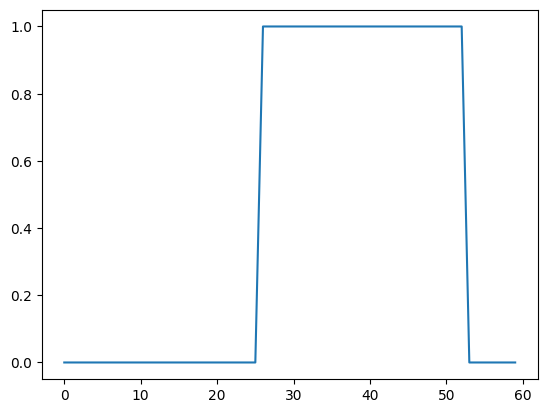

In [84]:
plt.plot(test[:60,0,0])

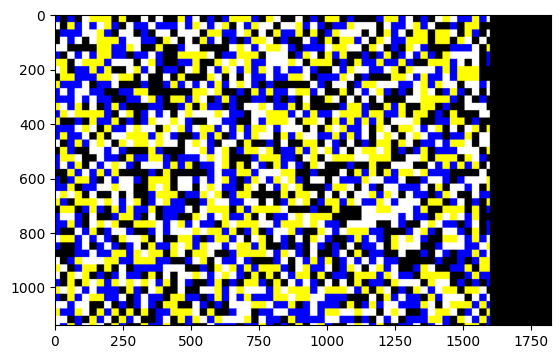

In [85]:
plt.imshow(test)

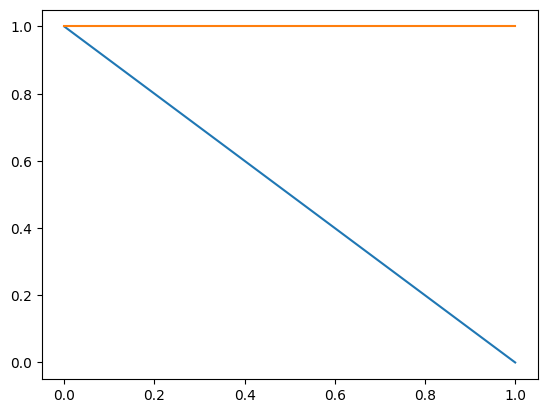

In [67]:
plt.plot(d_wn['steps'][0,:100,0])
plt.plot(d_wn['steps'][0,:100,1])